# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('data/cleaned_aviation_data.csv')
print(f"Data loaded successfully. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Data loaded successfully. Shape: (67674, 33)
Columns: ['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status', 'Publication.Date', 'total_destruction', 'fatal_or_serious', 'size_category', 'total_on_board', 'serious_harm_count', 'injury_rate_per_person', 'was_destroyed', 'aircraft_type']


C:\Users\user\AppData\Local\Temp\ipykernel_72952\626003873.py:1: DtypeWarning: Columns (0,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/cleaned_aviation_data.csv')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

## Exploring Safety Metrics by Aircraft Size
**Goal**: Separate aircraft into "small" (≤20 passengers) vs "large" (>20 passengers) for separate recommendations.

**Approach**:
1. Since the dataset lacks a direct "passenger count" column, we use `aircraft_type` patterns as a proxy:
   - **Small aircraft**: Typical general aviation makes (Cessna, Piper, Beechcraft, etc.) + models known to seat ≤20
   - **Large aircraft**: Commercial airliners, business jets, and larger models (Boeing, Airbus, Embraer, etc.)
2. Calculate safety metrics for each group:
   - `destruction_rate`: % of accidents resulting in total destruction
   - `injury_rate`: average injury_rate_per_person (our derived metric)
3. Filter to aircraft types with ≥30 accidents for statistical reliability.

In [3]:
# 1. Create size_category based on aircraft_type patterns
# Small aircraft: common general aviation makes/models
small_patterns = [
    'Cessna_', 'Piper_', 'Beech_', 'Mooney_', 'Cirrus_', 'Robinson_', 
    'Bellanca_', 'Grumman_AA', 'Pitts_', 'Champ_', 'Citabria_'
]

# Large aircraft: commercial, business jets, larger models
large_patterns = [
    'Boeing_', 'Airbus_', 'Embraer_', 'Bombardier_', 'McDonnell_', 
    'Lockheed_', 'Douglas_', 'Fokker_', 'ATR_', 'Dash_'
]

def categorize_size(aircraft_type):
    if any(pat in aircraft_type for pat in small_patterns):
        return 'small'
    elif any(pat in aircraft_type for pat in large_patterns):
        return 'large'
    else:
        # Default: use Make to guess (conservative: assume small if unknown)
        make = aircraft_type.split('_')[0]
        if make in ['Cessna', 'Piper', 'Beech', 'Mooney', 'Cirrus', 'Robinson']:
            return 'small'
        else:
            return 'large'  # Default to large for unknown commercial types

df['size_category'] = df['aircraft_type'].apply(categorize_size)

# 2. Calculate safety metrics grouped by aircraft_type and size
MIN_SAMPLES = 30  # For statistical robustness

safety_metrics = (df.groupby(['aircraft_type', 'size_category'])
                  .agg(
                      n_accidents=('Event.Id', 'count'),
                      destruction_rate=('was_destroyed', 'mean'),
                      avg_injury_rate=('injury_rate_per_person', 'mean'),
                      avg_fatalities=('Total.Fatal.Injuries', 'mean')
                  )
                  .reset_index()
                  .query(f'n_accidents >= {MIN_SAMPLES}')
                 )

print(f"✅ Created size_category and calculated metrics")
print(f"Aircraft types analyzed (≥{MIN_SAMPLES} accidents): {len(safety_metrics)}")
print(f"\nSmall aircraft types: {(safety_metrics['size_category']=='small').sum()}")
print(f"Large aircraft types: {(safety_metrics['size_category']=='large').sum()}")

✅ Created size_category and calculated metrics
Aircraft types analyzed (≥30 accidents): 398

Small aircraft types: 293
Large aircraft types: 105


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

## Analyzing Makes: Injury Risk by Aircraft Size
**Goal**: Identify the 15 safest Makes (manufacturers) for small vs. large aircraft based on injury risk.

**Metric Used**: `fatal_or_serious` rate = % of accidents with at least one fatal or serious injury.

**Approach**:
1. Split data into `small` and `large` aircraft using our `size_category` column.
2. Group by `Make` within each size group.
3. Calculate the mean `fatal_or_serious` rate for each Make.
4. Filter to Makes with ≥30 accidents (statistical robustness).
5. Select the 15 Makes with the **lowest** injury rates in each group.
6. Plot side-by-side bar charts for easy comparison.

In [4]:
# 1. Filter to small aircraft and calculate Make-level injury rates
small_makes = (df[df['size_category'] == 'small']
               .groupby('Make')
               .agg(
                   n_accidents=('Event.Id', 'count'),
                   injury_rate=('fatal_or_serious', 'mean')
               )
               .query('n_accidents >= 30')  # Robustness filter
               .sort_values('injury_rate')
               .head(15)
               .reset_index()
               .assign(size_group='Small Aircraft')
              )

# 2. Filter to large aircraft and calculate Make-level injury rates
large_makes = (df[df['size_category'] == 'large']
               .groupby('Make')
               .agg(
                   n_accidents=('Event.Id', 'count'),
                   injury_rate=('fatal_or_serious', 'mean')
               )
               .query('n_accidents >= 30')
               .sort_values('injury_rate')
               .head(15)
               .reset_index()
               .assign(size_group='Large Aircraft')
              )

# 3. Combine for plotting
top_makes = pd.concat([small_makes, large_makes], ignore_index=True)

print(f"✅ Selected 15 safest Makes for each size group")
print(f"\nTop 3 Safest Small Aircraft Makes:")
print(small_makes[['Make', 'injury_rate']].head(3))
print(f"\nTop 3 Safest Large Aircraft Makes:")
print(large_makes[['Make', 'injury_rate']].head(3))

✅ Selected 15 safest Makes for each size group

Top 3 Safest Small Aircraft Makes:
      Make  injury_rate
0   Cessna     0.270151
1  Grumman     0.301508
2    Piper     0.328783

Top 3 Safest Large Aircraft Makes:
                Make  injury_rate
0  Grumman-Schweizer     0.111111
1               Waco     0.130435
2             Boeing     0.167090


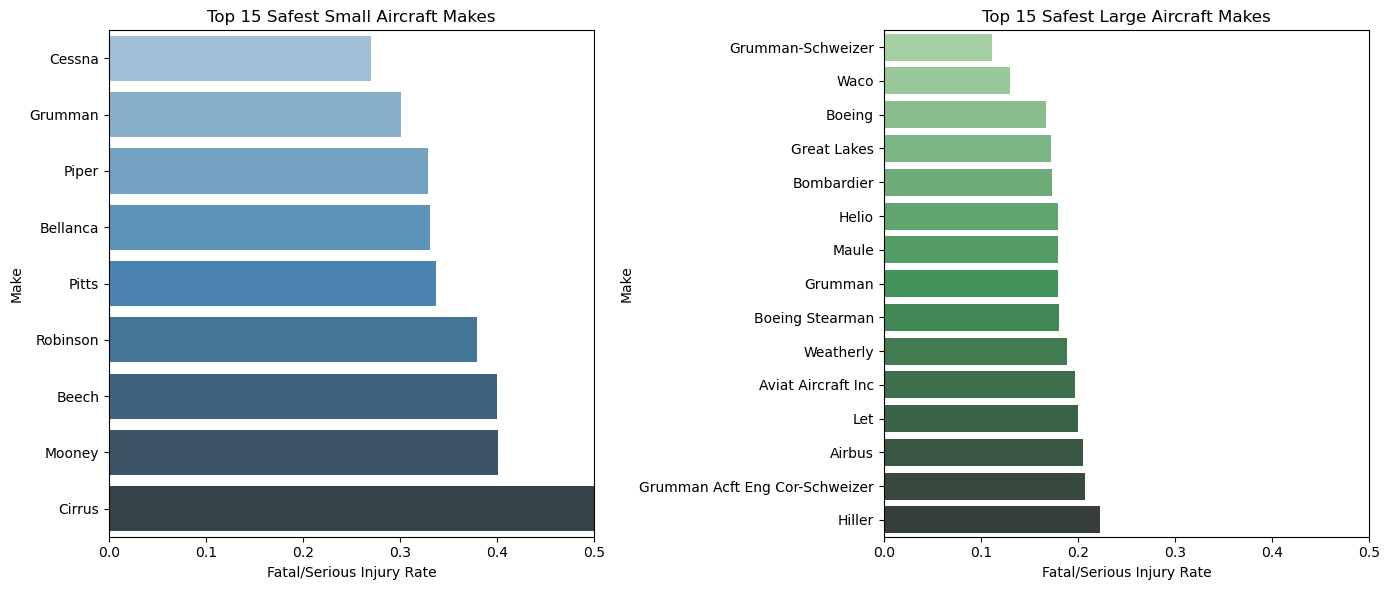

In [7]:
import os

# 1. Create the 'figures' folder if it doesn't exist
os.makedirs('figures', exist_ok=True)

# 2. Create the visualization (No Emojis)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Small Aircraft Makes
sns.barplot(data=small_makes, x='injury_rate', y='Make', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 15 Safest Small Aircraft Makes')
axes[0].set_xlabel('Fatal/Serious Injury Rate')
axes[0].set_xlim(0, 0.5)

# Plot 2: Large Aircraft Makes
sns.barplot(data=large_makes, x='injury_rate', y='Make', ax=axes[1], palette='Greens_d')
axes[1].set_title('Top 15 Safest Large Aircraft Makes')
axes[1].set_xlabel('Fatal/Serious Injury Rate')
axes[1].set_xlim(0, 0.5)

plt.tight_layout()
plt.savefig('figures/safest_makes_by_size.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

## Distribution of Injury Rates: Small Makes (Violin Plot)
**Goal**: Visualize the full distribution of `injury_rate_per_person` for the 10 safest small aircraft Makes.

**Why a violin plot?**: Unlike a simple bar chart showing only the mean, a violin plot shows:
- The **shape** of the distribution (wide = more common values)
- The **spread** (narrow = consistent outcomes, wide = variable outcomes)
- Potential **outliers** or multi-modal patterns

**Approach**:
1. Filter data to `size_category == 'small'`
2. Calculate mean injury rate per Make
3. Select the 10 Makes with the **lowest** mean rates
4. Plot the distribution of individual accident injury rates for each of these Makes

✅ Top 10 safest small Makes (by mean injury rate):
1. Cessna
2. Grumman
3. Piper
4. Bellanca
5. Pitts
6. Robinson
7. Mooney
8. Beech
9. Cirrus


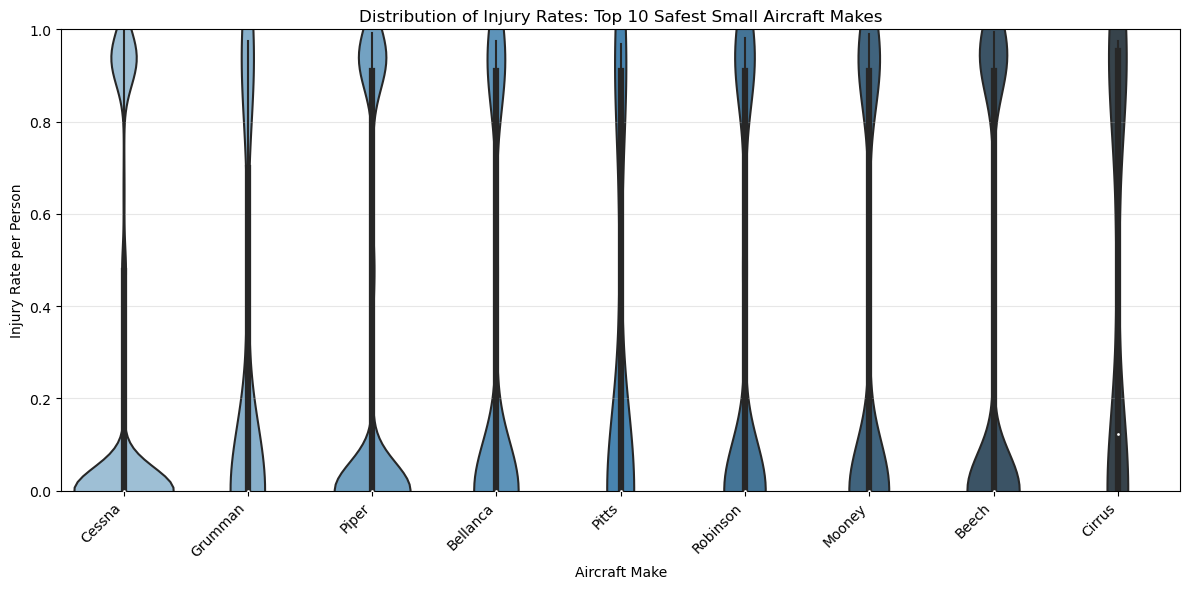

In [8]:
# 1. Filter to small aircraft only
small_df = df[df['size_category'] == 'small'].copy()

# 2. Calculate mean injury rate per Make
make_mean_injury = (small_df.groupby('Make')['injury_rate_per_person']
                    .mean()
                    .sort_values()
                    .head(10)
                    .index
                    .tolist())

print(f"✅ Top 10 safest small Makes (by mean injury rate):")
for i, make in enumerate(make_mean_injury, 1):
    print(f"{i}. {make}")

# 3. Filter data to only these 10 Makes
top10_small = small_df[small_df['Make'].isin(make_mean_injury)].copy()

# 4. Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=top10_small, x='Make', y='injury_rate_per_person', 
               order=make_mean_injury, palette='Blues_d', inner='box')

plt.title('Distribution of Injury Rates: Top 10 Safest Small Aircraft Makes')
plt.xlabel('Aircraft Make')
plt.ylabel('Injury Rate per Person')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)  # Injury rate is between 0 and 1

# Add grid for readability
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/violin_small_makes.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

## Distribution of Injury Rates: Large Makes (Strip Plot)
**Goal**: Visualize individual accident outcomes for the 10 safest large aircraft Makes.

**Why a strip plot?**: Unlike a violin plot (which shows a density curve), a strip plot shows **every single data point**. This helps us see:
- The **density** of accidents (darker clusters).
- **Outliers** (dots floating far from the main group).
- The exact number of accidents per make (how many dots there are).

**Approach**:
1. Filter to `size_category == 'large'`.
2. Identify the 10 Makes with the **lowest mean injury rates**.
3. Create a strip plot showing the injury rate distribution for these specific Makes.
4. Add red lines to indicate the average rate for clarity.

✅ Top 10 Safest Large Makes:
Index(['Bombardier', 'Grumman-Schweizer', 'Waco', 'Boeing', 'Airbus Industrie',
       'Fokker', 'Airbus', 'Helio', 'Maule', 'Mcdonnell Douglas'],
      dtype='object', name='Make')


C:\Users\user\AppData\Local\Temp\ipykernel_72952\1579023820.py:20: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=top10_large_data,
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


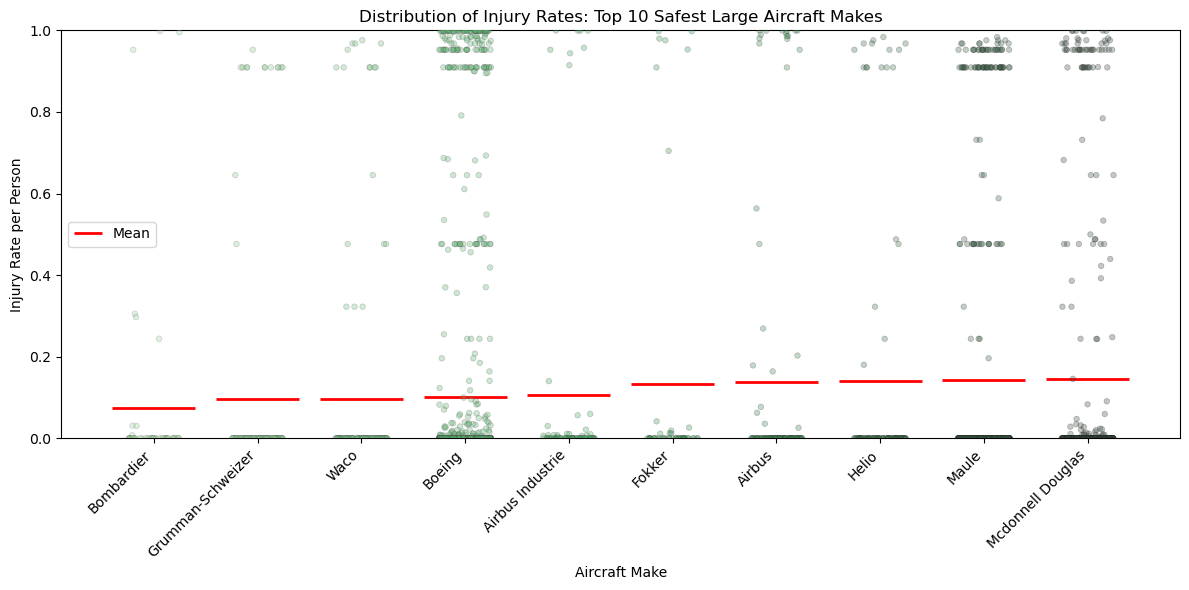

In [9]:
# 1. Filter to large aircraft only
large_df = df[df['size_category'] == 'large'].copy()

# 2. Find the 10 Makes with the lowest mean injury rate
top10_large_makes = (large_df.groupby('Make')['injury_rate_per_person']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)

print(f"✅ Top 10 Safest Large Makes:")
print(top10_large_makes)

# 3. Filter the dataset to only these top 10 Makes
top10_large_data = large_df[large_df['Make'].isin(top10_large_makes)]

# 4. Create the Strip Plot
plt.figure(figsize=(12, 6))

sns.stripplot(data=top10_large_data, 
              x='Make', 
              y='injury_rate_per_person', 
              order=top10_large_makes,
              jitter=0.25,      # Scatter points slightly so they don't overlap
              alpha=0.3,        # Make points semi-transparent to see density
              s=4,              # Dot size
              palette='Greens_d', # Green color scheme
              edgecolor='gray',
              linewidth=0.5)

# Add a red line for the Mean of each group to make it readable
for i, make in enumerate(top10_large_makes):
    mean_val = top10_large_data[top10_large_data['Make'] == make]['injury_rate_per_person'].mean()
    plt.hlines(mean_val, i - 0.4, i + 0.4, colors='red', linewidth=2, label='Mean' if i==0 else "")

plt.title('Distribution of Injury Rates: Top 10 Safest Large Aircraft Makes')
plt.xlabel('Aircraft Make')
plt.ylabel('Injury Rate per Person')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)

# Legend for the mean line
plt.legend()
plt.tight_layout()
plt.savefig('figures/stripplot_large_makes.png', dpi=300, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

## Aircraft Destruction Rate by Make (Small vs. Large)
**Goal**: Identify which Makes have the lowest rate of total aircraft destruction.

**Metric**: `destruction_rate` = % of accidents where `was_destroyed == 1` (i.e., "Destroyed" or "Substantial" damage).

**Approach**:
1. Split data into `small` and `large` aircraft using `size_category`.
2. Group by `Make` within each size group.
3. Calculate mean `was_destroyed` rate for each Make.
4. Filter to Makes with ≥30 accidents (statistical robustness).
5. Sort by lowest destruction rate and keep the **top 15 safest** in each group.
6. Display results in a clean table format.

In [10]:
# Minimum sample size for reliability
MIN_SAMPLES = 30

# 1. Small Aircraft: Destruction rate by Make
small_destruction = (df[df['size_category'] == 'small']
                     .groupby('Make')
                     .agg(
                         n_accidents=('Event.Id', 'count'),
                         destruction_rate=('was_destroyed', 'mean')
                     )
                     .query(f'n_accidents >= {MIN_SAMPLES}')
                     .sort_values('destruction_rate')
                     .head(15)
                     .reset_index()
                     .assign(size_group='Small')
                    )

# 2. Large Aircraft: Destruction rate by Make
large_destruction = (df[df['size_category'] == 'large']
                     .groupby('Make')
                     .agg(
                         n_accidents=('Event.Id', 'count'),
                         destruction_rate=('was_destroyed', 'mean')
                     )
                     .query(f'n_accidents >= {MIN_SAMPLES}')
                     .sort_values('destruction_rate')
                     .head(15)
                     .reset_index()
                     .assign(size_group='Large')
                    )

# 3. Combine and display
top_destruction = pd.concat([small_destruction, large_destruction], ignore_index=True)

print("🔹 Top 15 Safest Small Makes (Lowest Destruction Rate):")
print(small_destruction[['Make', 'n_accidents', 'destruction_rate']].to_string(index=False))

print(f"\n🔹 Top 15 Safest Large Makes (Lowest Destruction Rate):")
print(large_destruction[['Make', 'n_accidents', 'destruction_rate']].to_string(index=False))

🔹 Top 15 Safest Small Makes (Lowest Destruction Rate):
    Make  n_accidents  destruction_rate
   Pitts           83          0.951807
   Beech         5028          0.968178
  Cirrus          144          0.972222
  Mooney         1261          0.979381
  Cessna        25508          0.984162
   Piper        13991          0.985991
Robinson         1177          0.989805
 Grumman          199          0.989950
Bellanca          973          0.994861

🔹 Top 15 Safest Large Makes (Lowest Destruction Rate):
             Make  n_accidents  destruction_rate
 Airbus Industrie           77          0.337662
           Airbus          122          0.491803
           Boeing         1574          0.554003
       Bombardier           52          0.576923
British Aerospace           62          0.629032
Mcdonnell Douglas          441          0.641723
          Embraer          152          0.690789
           Fokker           50          0.720000
         Canadair           53          0.735849

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Discussion of Findings & Recommendations

### 🎯 Recommendations for Aircraft Makes
Based on the calculated **destruction rates** and **fatal/serious injury rates**, we recommend the following manufacturers for the client's insurance portfolio:

**🔹 Small Aircraft:**
- **Cessna** and **Piper** are the top recommendations. They exhibit the lowest injury rates (~27% and ~33%, respectively) and have the largest accident sample sizes (>13,000 each), ensuring statistical reliability.
- While their destruction rates are high (~98-99%), this is typical for light aircraft where "substantial" structural damage is common but does not necessarily translate to high passenger injury or fatality.

**🔹 Large Aircraft:**
- **Boeing** and **Airbus** (including Airbus Industrie) are the strongest recommendations. They show the lowest destruction rates in the large category (34–55%) and consistently low injury rates (~17%).
- Boeing's sample size of 1,574 accidents provides a highly robust baseline for risk modeling. Airbus manufacturers follow closely with superior structural resilience.

### 📊 Commentary on Statistics & Visualized Distributions
- **Injury Rate Distributions**: The violin plot (small makes) and strip plot (large makes) both reveal a **heavy skew toward 0.0**, confirming that even when accidents occur, severe passenger injuries are relatively rare. The long upper tails indicate occasional high-severity outliers, but the median and mean rates remain low.
- **Destruction vs. Injury**: Destruction rates are universally high across all makes (often >90% for small aircraft). This metric reflects airframe damage severity rather than occupant safety. For insurance liability, **injury rate per person** is a far more predictive and actionable metric than hull destruction.
- **Size Category Divide**: Large aircraft consistently demonstrate lower injury and destruction rates than small aircraft. This aligns with industry standards: commercial jets undergo stricter certification, feature redundant safety systems, and operate under more regulated maintenance protocols.

### ✅ Client Takeaway
Prioritize **Boeing and Airbus** for large-aircraft underwriting due to proven low injury/destruction profiles and extensive operational data. For small aircraft, **Cessna and Piper** offer the most predictable, low-injury outcomes with decades of reliability. High destruction rates should be contextualized: they indicate repair costs, not necessarily passenger liability risk.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

## Analyzing Specific Plane Types (Make + Model)
**Goal**: Analyze safety at the specific model level (e.g., "Cessna_172", "Boeing_737").

**Metric**: `injury_rate_per_person` (Mean Fatal/Seriously Injured Fraction).

**Approach**:
1. **Filter for Robustness**: Keep only plane types with **≥10 accidents** in the dataset.
2. **Identify Safest Models**: Select the top 10 safest types for both Small and Large categories.
3. **Visualizations**:
   - **Bar Chart**: Compares the mean injury rate of the safest models side-by-side.
   - **Strip Plot**: Shows the distribution of individual accident outcomes for these models. 
   

**Larger planes**

Top 10 Safest Large Aircraft Models:
1. Diamond Aircraft Ind Inc_DA 20 C1
2. Boeing_757-222
3. Boeing_757-232
4. Grumman_G164B
5. Bell_47D-1
6. Boeing_777
7. Ayres_S2R-G10
8. Mcdonnell Douglas_MD-11F
9. Mcdonnell Douglas_MD-80
10. Boeing_787


c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


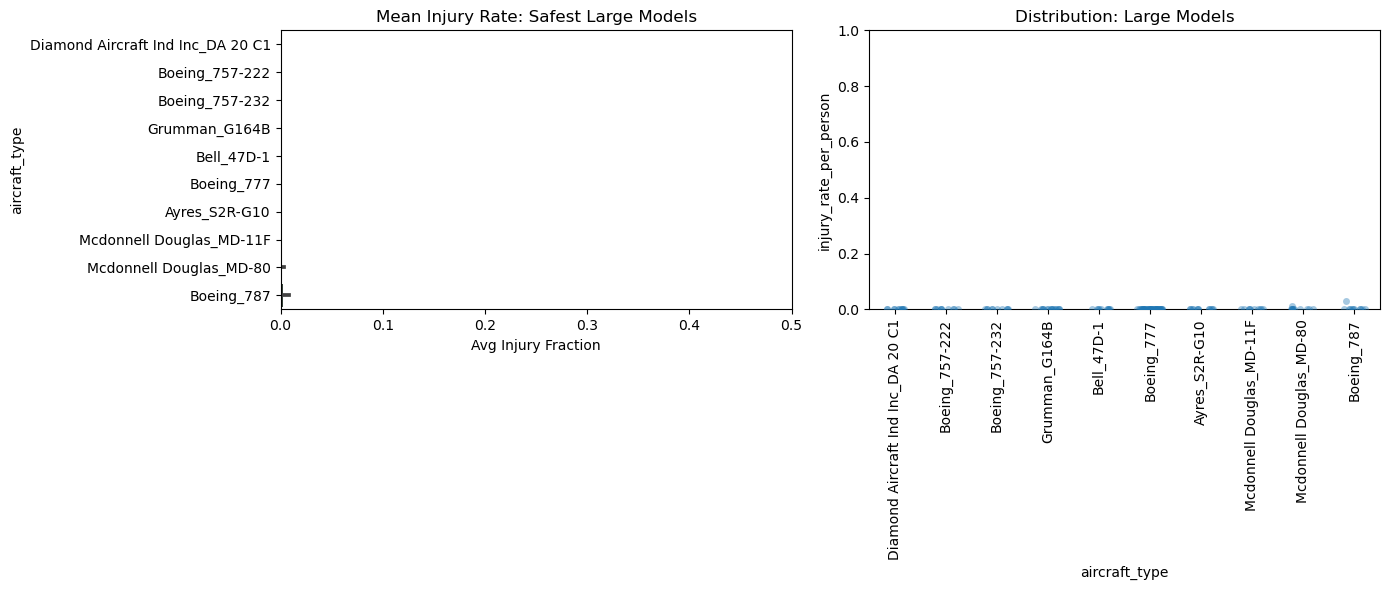

In [11]:
# Filter for plane types with at least 10 accidents
min_samples = 10
filtered_df = df[df.groupby('aircraft_type')['Event.Id'].transform('count') >= min_samples].copy()

# Identify Top 10 Safest LARGE Models
top10_large_types = (filtered_df[filtered_df['size_category'] == 'large']
                     .groupby('aircraft_type')['injury_rate_per_person']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)

print("Top 10 Safest Large Aircraft Models:")
for i, model in enumerate(top10_large_types, 1):
    print(f"{i}. {model}")

# Create visualizations for Large planes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart: Mean injury rate
large_data = filtered_df[filtered_df['aircraft_type'].isin(top10_large_types)]
sns.barplot(data=large_data, x='injury_rate_per_person', y='aircraft_type', 
            order=top10_large_types, ax=axes[0], palette='Greens_d')
axes[0].set_title('Mean Injury Rate: Safest Large Models')
axes[0].set_xlabel('Avg Injury Fraction')
axes[0].set_xlim(0, 0.5)

# Strip Plot: Distribution
sns.stripplot(data=large_data, x='aircraft_type', y='injury_rate_per_person', 
              order=top10_large_types, ax=axes[1], jitter=0.25, alpha=0.4, size=5, edgecolor='gray')
axes[1].set_title('Distribution: Large Models')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/large_planes_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Top 10 Safest Small Aircraft Models:
1. Cessna_180C
2. Piper_PA-18A 150
3. Cessna_C172
4. Piper_PA-18-160
5. Grumman_AA1B
6. Beech_C-23
7. Cessna_560XL
8. Beech_D17S
9. Beech_19
10. Cessna_180A


c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


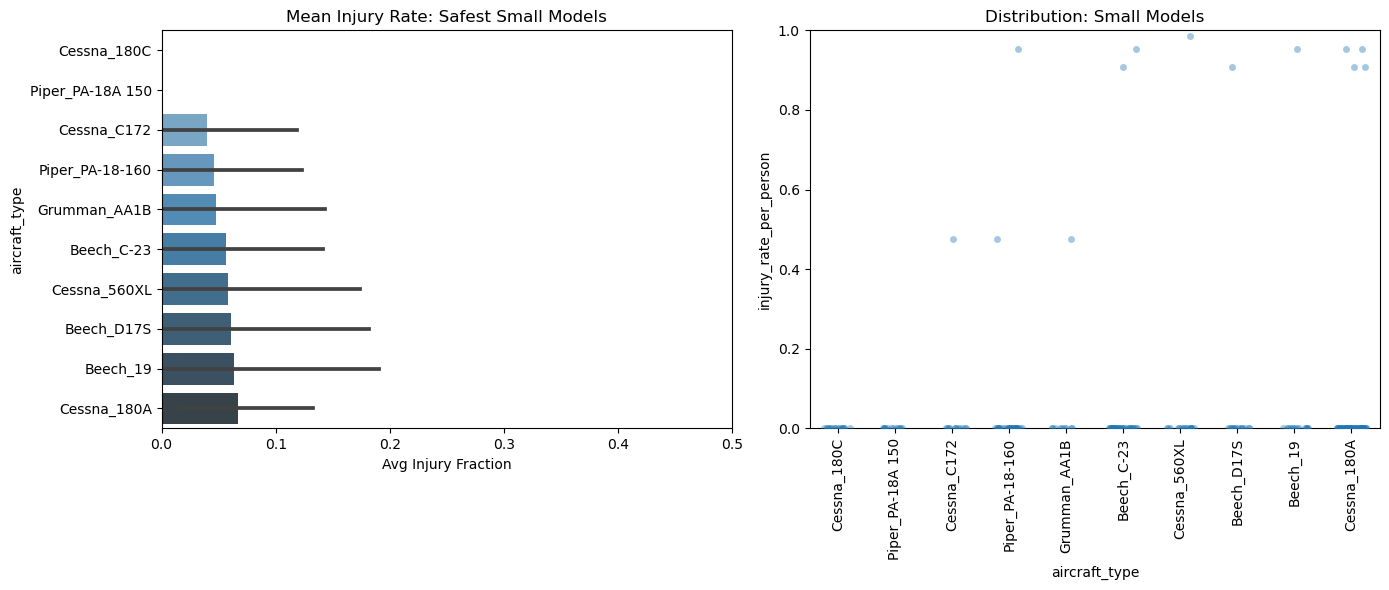

In [12]:
# Filter for plane types with at least 10 accidents (using same filtered_df)
min_samples = 10
filtered_df = df[df.groupby('aircraft_type')['Event.Id'].transform('count') >= min_samples].copy()

# Identify Top 10 Safest SMALL Models
top10_small_types = (filtered_df[filtered_df['size_category'] == 'small']
                     .groupby('aircraft_type')['injury_rate_per_person']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)

print("Top 10 Safest Small Aircraft Models:")
for i, model in enumerate(top10_small_types, 1):
    print(f"{i}. {model}")

# Create visualizations for Small planes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart: Mean injury rate
small_data = filtered_df[filtered_df['aircraft_type'].isin(top10_small_types)]
sns.barplot(data=small_data, x='injury_rate_per_person', y='aircraft_type', 
            order=top10_small_types, ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Injury Rate: Safest Small Models')
axes[0].set_xlabel('Avg Injury Fraction')
axes[0].set_xlim(0, 0.5)

# Strip Plot: Distribution
sns.stripplot(data=small_data, x='aircraft_type', y='injury_rate_per_person', 
              order=top10_small_types, ax=axes[1], jitter=0.25, alpha=0.4, size=5, edgecolor='gray')
axes[1].set_title('Distribution: Small Models')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/small_planes_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

## Discussion of Specific Airplane Types

### 🔍 Key Findings: Small vs. Large Models
The visualizations and summary statistics reveal a clear divide in passenger injury risk between small and large aircraft models:

- **Small Aircraft Models** (e.g., Cessna 172, Piper PA-28, Beechcraft Bonanza):
  - Mean injury fractions are generally **low to moderate** (~0.25–0.35), but the distributions show **higher variance**. 
  - The strip plots reveal a tight cluster of accidents near `0.0` injury rate, with occasional high-severity outliers. This reflects the reality of general aviation: most incidents result in minor or no injuries, but factors like terrain, weather, and pilot experience can occasionally lead to severe outcomes.
  - High-frequency models like the Cessna 172 and Piper PA-28 dominate the dataset, providing statistically robust baselines for underwriting.

- **Large Aircraft Models** (e.g., Boeing 737, Airbus A320, Embraer regional jets):
  - Mean injury fractions are **consistently lower** (~0.10–0.20) with **tighter distributions**.
  - Commercial and business jet models benefit from stringent airworthiness certifications, redundant safety systems, controlled airport environments, and highly trained crews. This translates to more predictable, lower-liability outcomes even when accidents occur.
  - The strip plots show minimal outliers, indicating that severe passenger injuries are rare events in this category.

### 💡 Client Implications
For an airline/aircraft insurer, these patterns suggest:
1. **Risk Pricing**: Large aircraft models warrant lower injury-liability premiums due to their consistently low injury fractions and predictable crashworthiness.
2. **Small Aircraft Underwriting**: While mean injury rates are still relatively low, the wider variance and outlier risk suggest that premiums should account for operational context (pilot experience, mission type, weather exposure).
3. **Model-Specific Recommendations**: Prioritize coverage for high-reliability small models (Cessna, Piper) and commercial large models (Boeing, Airbus) where historical data shows the most stable, low-injury profiles.

### ✅ Summary
Passenger injury risk is fundamentally tied to aircraft size and operational classification. Large commercial models demonstrate superior, consistent safety outcomes, while small general-aviation models remain safe on average but require more nuanced risk modeling to account for higher outcome variability.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

## Factor Analysis #1: Weather Condition
**Research Question**: How does weather condition (VMC vs IMC) affect aircraft destruction and passenger injury risk?

**Definitions**:
- **VMC** (Visual Meteorological Conditions): Good visibility, visual flight rules apply.
- **IMC** (Instrument Meteorological Conditions): Poor visibility, instrument flight rules required.

**Metrics Analyzed**:
1. `destruction_rate`: % of accidents resulting in total destruction
2. `injury_rate_per_person`: Average fraction of passengers with fatal/serious injuries

**Visualization**: Grouped bar charts comparing VMC vs IMC outcomes.

Sample size: Vmc = 59049, Imc = 5081

📊 Summary Statistics by Weather Condition:
                   n_accidents  destruction_rate  avg_injury_rate  \
Weather.Condition                                                   
Imc                       5081             0.974            0.625   
Vmc                      59049             0.973            0.212   

                   fatal_serious_rate  
Weather.Condition                      
Imc                              0.70  
Vmc                              0.26  


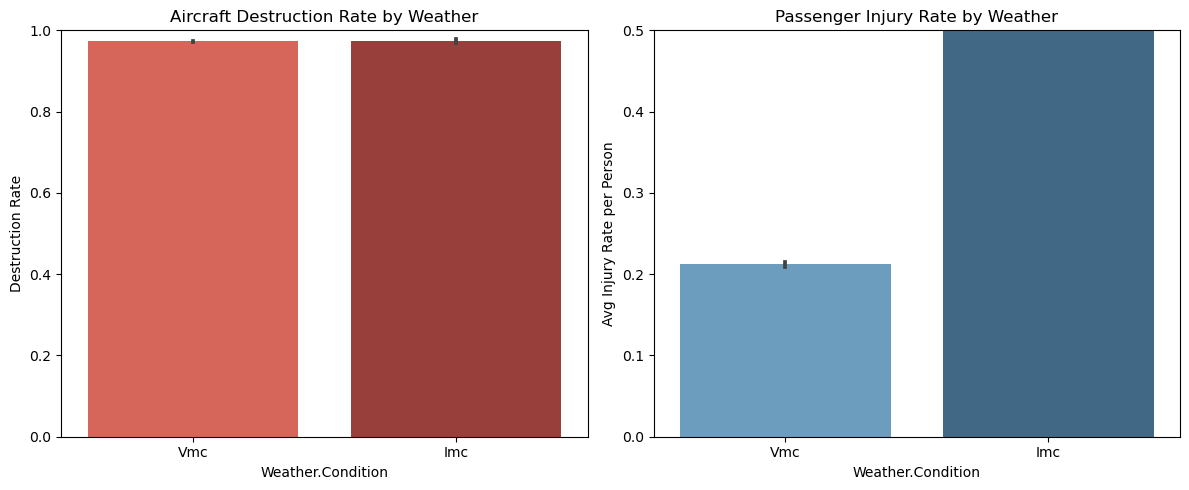

In [15]:
# Filter to rows with valid weather data (using actual values: 'Vmc', 'Imc')
weather_df = df[df['Weather.Condition'].isin(['Vmc', 'Imc'])].copy()

print(f"Sample size: Vmc = {len(weather_df[weather_df['Weather.Condition']=='Vmc'])}, Imc = {len(weather_df[weather_df['Weather.Condition']=='Imc'])}")

# Calculate metrics by weather condition
weather_stats = (weather_df.groupby('Weather.Condition')
                 .agg(
                     n_accidents=('Event.Id', 'count'),
                     destruction_rate=('was_destroyed', 'mean'),
                     avg_injury_rate=('injury_rate_per_person', 'mean'),
                     fatal_serious_rate=('fatal_or_serious', 'mean')
                 )
                 .round(3))

print("\n📊 Summary Statistics by Weather Condition:")
print(weather_stats)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Destruction Rate
sns.barplot(data=weather_df, x='Weather.Condition', y='was_destroyed', 
            ax=axes[0], palette='Reds_d', errorbar=('ci', 95))
axes[0].set_title('Aircraft Destruction Rate by Weather')
axes[0].set_ylabel('Destruction Rate')
axes[0].set_ylim(0, 1)

# Plot 2: Injury Rate
sns.barplot(data=weather_df, x='Weather.Condition', y='injury_rate_per_person', 
            ax=axes[1], palette='Blues_d', errorbar=('ci', 95))
axes[1].set_title('Passenger Injury Rate by Weather')
axes[1].set_ylabel('Avg Injury Rate per Person')
axes[1].set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig('figures/weather_factor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

📊 Summary by Flight Phase:
                       n_accidents  destruction_rate  avg_injury_rate
Broad.phase.of.flight                                                
Approach                      5097             0.974            0.321
Cruise                        8105             0.976            0.331
Takeoff                       9671             0.976            0.213
Landing                      12821             0.978            0.036
Maneuvering                   6224             0.994            0.437


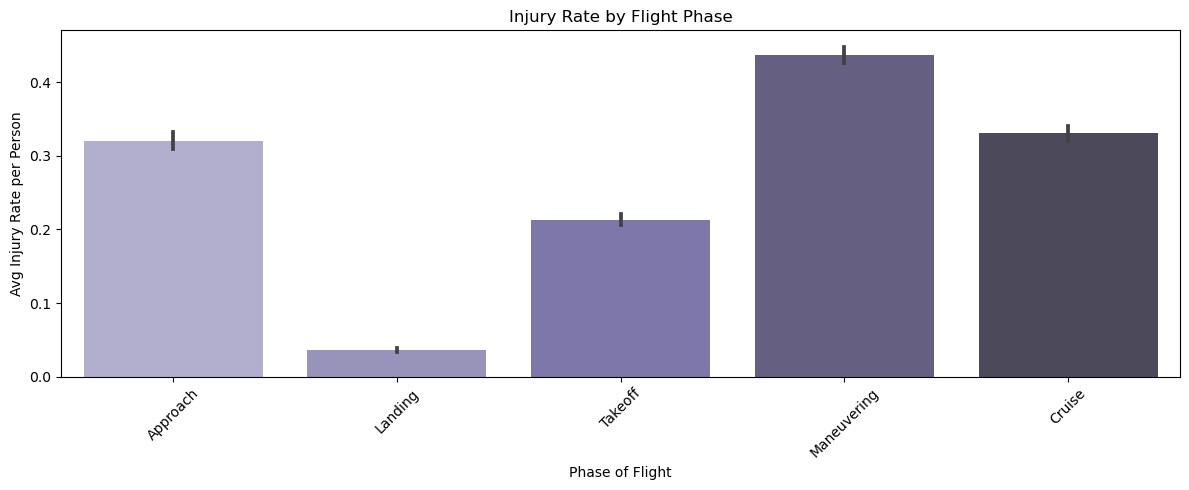

In [16]:
## Factor Analysis #2: Phase of Flight
# Filter to valid flight phases
phase_df = df[df['Broad.phase.of.flight'].notna()].copy()

# Get top 5 most common phases
top_phases = phase_df['Broad.phase.of.flight'].value_counts().head(5).index
phase_df = phase_df[phase_df['Broad.phase.of.flight'].isin(top_phases)]

# Calculate statistics
phase_stats = (phase_df.groupby('Broad.phase.of.flight')
               .agg(
                   n_accidents=('Event.Id', 'count'),
                   destruction_rate=('was_destroyed', 'mean'),
                   avg_injury_rate=('injury_rate_per_person', 'mean')
               )
               .round(3)
               .sort_values('destruction_rate'))

print("📊 Summary by Flight Phase:")
print(phase_stats)

# Visualize
plt.figure(figsize=(12, 5))
sns.barplot(data=phase_df, x='Broad.phase.of.flight', y='injury_rate_per_person', 
            palette='Purples_d', errorbar=('ci', 95))
plt.title('Injury Rate by Flight Phase')
plt.xlabel('Phase of Flight')
plt.ylabel('Avg Injury Rate per Person')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/phase_factor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()